# Deep Learning and Neural Networks with Applications**

# **Week 6 Lab - RNNs**

In this lab, we will explore a basic (vanilla) RNN and two of its variants across three tasks:

- **Task 1**: Implement a vanilla RNN to predict stock prices. This task has 7 questions, and you should answer all of them. **Important:** This task uses the "yfinance" library, which sometimes causes issues when run locally. **It is preferred you run this lab on Google Colab.**

- **Task 2**: Implement an LSTM RNN for sentiment analysis. This task involves text data, therefore we will learn some pre-processing we can apply to convert words into sequences of numbers using a **vocabulary**. This task has 5 questions, and you should answer all of them.

- **Task 3**: Implement an encoder-decoder RNN architecture on a synthetic sequence-to-sequence task. This task will also use a **vocabulary**. This task has 3 questions, and you should answer all of them.

 **Important: Using a free GPU on Google Colab will help improve the speed of execution of all tasks in this lab. To use a GPU on Google Colab, go to "Runtime", then select "Change runtime type", select one of the available GPUs under "Hardware accelerator" (e.g. T4 GPU) and click "Save".**

## **General Instructions**
1. Read the explanatory text and run each code chunk sequentially.
2. Questions for each task appear throughout the notebook. Add your answers by following the specific instructions. Some questions require coding, while others require analysis based on one or more code outputs.
3. After answering all questions, submit your notebook through the corresponding QMPlus link for this lab assignment.

**Note:** This and all subsequent labs assume that you have completed the previous labs. In particular, you are expected to be familiar with code for: (1) defining a neural network model using `nn.Module`; (2) defining a training function for your model, including choosing an optimiser and loss function, setting and using hyperparameters such as the number of epochs, and implementing the forward and backward passes; and (3) defining and using a test function to evaluate your model on a validation or test dataset. Moving forward, our labs will prioritise critical analysis and the broader implications of these concepts over writing code from scratch.

As a preliminary step, let's import all libraries we will need for this lab. We will also set a fixed seed for the entire Notebook in case we run experiments with random components later on (for reproducibility).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler #To scale the data
from sklearn.metrics import mean_squared_error #To calculate the error
import yfinance as yf #To load our dataset for task 1

from collections import Counter #To count the number of occurrences of each class in the dataset
from torch.utils.data import DataLoader, TensorDataset #To create a dataloader for our dataset
from datasets import load_dataset #To load our dataset for task 2

torch.manual_seed(123) #Set a random seed for reproducibility

## Task 1: Vanilla RNN for Stock Price Prediction
In this task, we will implement a basic RNN (also called "vanilla" RNN) for predicting stock prices. We will download a real-world dataset using the yfinance library, which provides a Pythonic way to fetch financial and market data from Yahoo! Finance. We will load Apple (AAPL) data for the past five years and focus on the daily closing price.

In [ ]:
stock_data = yf.download('AAPL', start='2020-01-01', end='2025-12-31', progress=True)
stock_prices = stock_data['Close'].values
print(f"Loaded {len(stock_prices)} days of real stock data for Apple Inc.")

/tmp/ipykernel_1199/1803264226.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download('AAPL', start='2020-01-01', end='2025-12-31', progress=True)
[*********************100%***********************]  1 of 1 completed

Loaded 1507 days of real stock data for Apple Inc.


First, let's do a bit of data exploration and visualisation to better understand the dataset.

Data shape: (1507, 1)
Price range: $54.16 - $285.66
Mean price: $164.56


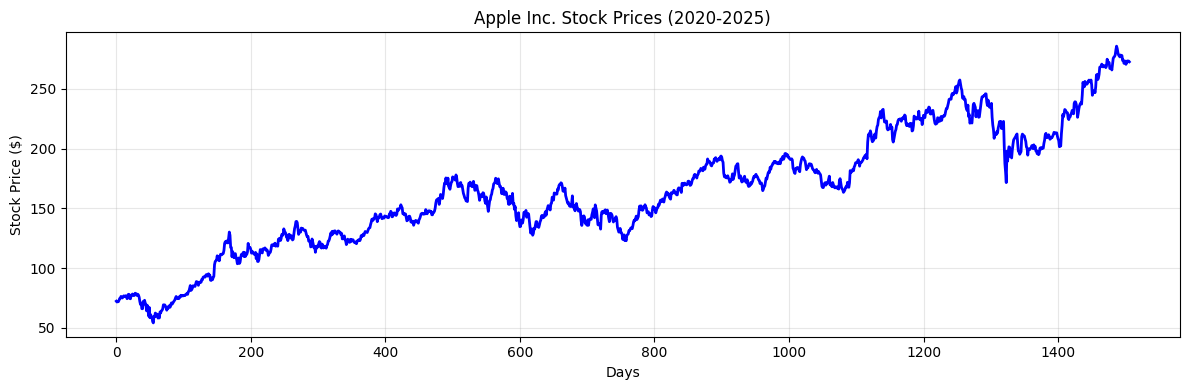

In [ ]:
print(f"Data shape: {stock_prices.shape}")
print(f"Price range: ${stock_prices.min():.2f} - ${stock_prices.max():.2f}")
print(f"Mean price: ${stock_prices.mean():.2f}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(stock_prices, linewidth=2, color='blue')
ax.set_xlabel('Days')
ax.set_ylabel('Stock Price ($)')
ax.set_title('Apple Inc. Stock Prices (2020-2025)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

To prepare the data for the RNN, we will normalise the values to the range 0-1.

In [ ]:
scaler_stock = MinMaxScaler(feature_range=(0, 1))
stock_scaled = scaler_stock.fit_transform(stock_prices.reshape(-1, 1))
print(f"Normalized data shape: {stock_scaled.shape}")

Normalized data shape: (1507, 1)


**Task 1 - Question 1:** Why is it important to normalise data when using deep neural networks?

**Answer:**

In normalisation, the input values are rescaled into a small range (0-1) using MinMaxScaler. It is important in deep learning as it keeps the gradient stable and it stops the gradient from exploding and vanishing. In week 6, during the RNN architecture lecture it was stated that there is weight sharing in Wxh, Whh and Why across all cells. Therefore raw values makes every cells W_xh.x_t (weighted sum) larger, which also increases the gradient. Also, during back propagation if scaling is a recurring problem throughout the sequence it can cause the exploding gradients. In week 3 lecture, the solution given to prevent vanishing and exploding gradients is by using batch normalisation to stabilise activations during training.

Now we define the input (x) and output (y) vectors. For each sample, x contains the stock prices from the previous 10 days, and y is the stock price on day 11. This is a many-to-one setup: the RNN processes a 10-step sequence and uses the final time step representation to predict a single next-day value. Both input and output use one feature (the closing stock price).

In [ ]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 10
X_stock, y_stock = create_sequences(stock_scaled, seq_length)
print(f"Number of sequences/recurrent cells created: {X_stock.shape[0]}")

Number of sequences/recurrent cells created: 1497


Next, we will split the dataset into training and test sets. For this lab, we will use the test set as a validation set, but in good practice these should be separate so you can tune hyperparameters before final testing. We will also convert the data to vectors so it can be used by the RNN.

In [ ]:
train_size = int(len(X_stock) * 0.8)
X_train_stock = torch.FloatTensor(X_stock[:train_size])
y_train_stock = torch.FloatTensor(y_stock[:train_size]).reshape(-1, 1)
X_test_stock = torch.FloatTensor(X_stock[train_size:])
y_test_stock = torch.FloatTensor(y_stock[train_size:]).reshape(-1, 1)

print(f"Training set size: {X_train_stock.shape[0]}")
print(f"Test set size: {X_test_stock.shape[0]}")

Training set size: 1197
Test set size: 300


Now we will define our vanilla RNN model. Important properties include hidden size (hidden_size) and number of layers (num_layers). The model uses torch.nn.RNN with the specified number of recurrent layers, followed by an nn.Linear layer to produce outputs of the required size.

In [ ]:
class VanillaRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(VanillaRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True) #To create a vanilla RNN model with the specified input size, hidden size, number of layers, and output size
        self.fc = nn.Linear(hidden_size, output_size) #To create a fully connected layer that maps the hidden state to the output size

    def forward(self, x):
        out, _ = self.rnn(x) #To pass the input through the RNN layer and get the output and hidden state
        out = out[:, -1, :] #To select the output of the last time step for each sequence in the batch
        out = self.fc(out) #To pass the output of the last time step through the fully connected layer to get the final output
        return out

**Task 1 - Question 2:** Check the documentation of torch.nn.RNN, available at https://docs.pytorch.org/docs/2.12/generated/torch.nn.RNN.html. Based on what we learned in our lectures and this description, what is special about this type of architecture?

**Answer:**

PyTorch states that the architecture torch.nn.RNN applies a multi-layer Elman RNN with ReLU or tahn non linearity to an input sequence. During labs 2-5, I used a CNN and MLP to process inputs independently, however these models are non sequential (meaning they don’t require memory from the past). However what makes RNN special is that it is a sequential network that has memory, which means it needs to know what came before. In week 6 lecture on RNN architecture, the networks memory is implemented using a hidden state in the temporal relationship between the output y and the input x at the current t.

Another reason why this network it special is because we only need to learn 3 weight vectors, as in Wxh, Whh and Why there is weight sharing across all cells. Temporal invariance, which is the ability to recognise a pattern regardless of when it happen, is the main reason for this. In this case weights are used for semantics regardless of its position in the sequence. This is also found in lecture 6 example, where the word today doesn’t change regardless of where in the sequence it is in.

Lastly, RNN’s are special due to its step by step processing style. Week 6 states that non sequential models process all elements at once, where as in sequential networks (RNN) elements are processed step by step in order for the past to be considered. This is evident in PyTorch uses for t in range(seq_len) for the past to be in the sequence one the step at a time.

Now, let's instantiate the network using the definition above. Since each input has only one feature, we use an input size of 1. We set hidden_size to 8, num_layers to 1, and output size to 1.

In [ ]:
vanilla_rnn = VanillaRNN(input_size=1, hidden_size=8, num_layers=1, output_size=1)

Let's briefly inspect the parameters (weights and biases) that we will need to learn.

In [ ]:
def print_parameter_sizes(model):
  print("\n Weights and biases of our vanilla RNN:")
  print("-" * 100)
  for name, param in model.named_parameters():
      shape_str = str(list(param.shape))
      print(f"Tensor Name: {name:<20} | Shape: {shape_str:<15} | Elements: {param.numel()}")

print_parameter_sizes(vanilla_rnn)


 Weights and biases of our vanilla RNN:
----------------------------------------------------------------------------------------------------
Tensor Name: rnn.weight_ih_l0     | Shape: [8, 1]          | Elements: 8
Tensor Name: rnn.weight_hh_l0     | Shape: [8, 8]          | Elements: 64
Tensor Name: rnn.bias_ih_l0       | Shape: [8]             | Elements: 8
Tensor Name: rnn.bias_hh_l0       | Shape: [8]             | Elements: 8
Tensor Name: fc.weight            | Shape: [1, 8]          | Elements: 8
Tensor Name: fc.bias              | Shape: [1]             | Elements: 1


Here, "l0" refers to the first recurrent layer, "ih" means input-to-hidden (W_xh in our lecture), "hh" means hidden-to-hidden (W_hh in our lecture), and "fc" corresponds to the output layer (W_hy in our lecture).

**Task 1 - Question 3:** How many weights + biases do we need to learn in this RNN?

**Answer:**

In lecture 6, RNN architecture slide, it states that we need to learn 3 weight vectors at each cell t. The first is the input weight W_xh, which considers the current input xt. In this lab exercise it is represented as rnn.weight_ih_l0, which is the input to hidden in the first recurrent layer. The second is W_hh, which considers the memory of the past ht-1. In this lab it is rnn.weight_hh_l0,which means hidden to hidden. Lastly, we need to learn W_hy, which produces the output from the current block. In this lab it is fc.weight. Below I will calculate the parameters (Weights and Biases) we need to learn for this RNN:

The Weights: 8 + 64 + 8 = 80

rnn.weight_ih_l0 = 8

rnn.weight_hh_l0 = 64

fc.weight = 8

The Bias: 8 + 8 + 1 = 17

rnn.bias_ih_l0 = 8

rnn.bias_hh_l0 = 8

fc.bias = 1

This RNN will need to learn 80 weights and 17 biases, therefore 97 parameters overall. This was done using the formula in the lecture slide adding complexity via dimensionality, where the dimensions of the weight and bias vectors are added together.

Next, we will define a training function for the RNN. We use MSE loss and the Adam optimiser.

In [ ]:
def train_vanilla_rnn(model, X_train, y_train, X_test, y_test, epochs=50, lr=0.01):
    criterion = nn.MSELoss() #To define the loss function as Mean Squared Error (MSE) for regression tasks
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) #To define the optimizer as Adam with the specified learning rate

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        outputs = model(X_train)
        loss = criterion(outputs, y_train) #compute the loss between the model's predictions and the true labels

        optimizer.zero_grad() #To clear the gradients of all optimized tensors before the backward pass
        loss.backward() #To compute the gradient of the loss with respect to the model parameters

        optimizer.step() #update the model parameters based on the computed gradients
        train_losses.append(loss.item()) #collect the training loss for this epoch

        model.eval() #evaluate the model on the test set without updating the weights
        with torch.no_grad():
            test_output = model(X_test)
            test_loss = criterion(test_output, y_test)
            test_losses.append(test_loss.item())
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {loss.item():.6f}")

    return train_losses, test_losses

Now, let's train the network using the function defined above.

In [ ]:
vanilla_losses_train, vanilla_losses_test = train_vanilla_rnn(vanilla_rnn, X_train_stock, y_train_stock, X_test_stock, y_test_stock, epochs=50)

Epoch 1/50 - Train Loss: 0.041063
Epoch 2/50 - Train Loss: 0.023229
Epoch 3/50 - Train Loss: 0.020994
Epoch 4/50 - Train Loss: 0.025258
Epoch 5/50 - Train Loss: 0.026122
Epoch 6/50 - Train Loss: 0.023282
Epoch 7/50 - Train Loss: 0.019570
Epoch 8/50 - Train Loss: 0.016980
Epoch 9/50 - Train Loss: 0.016087
Epoch 10/50 - Train Loss: 0.016319
Epoch 11/50 - Train Loss: 0.016596
Epoch 12/50 - Train Loss: 0.016076
Epoch 13/50 - Train Loss: 0.014591
Epoch 14/50 - Train Loss: 0.012573
Epoch 15/50 - Train Loss: 0.010702
Epoch 16/50 - Train Loss: 0.009525
Epoch 17/50 - Train Loss: 0.009102
Epoch 18/50 - Train Loss: 0.008879
Epoch 19/50 - Train Loss: 0.008086
Epoch 20/50 - Train Loss: 0.006466
Epoch 21/50 - Train Loss: 0.004520
Epoch 22/50 - Train Loss: 0.003091
Epoch 23/50 - Train Loss: 0.002582
Epoch 24/50 - Train Loss: 0.002362
Epoch 25/50 - Train Loss: 0.001490
Epoch 26/50 - Train Loss: 0.000356
Epoch 27/50 - Train Loss: 0.000510
Epoch 28/50 - Train Loss: 0.001795
Epoch 29/50 - Train Loss: 0.0

Now we will evaluate the trained RNN on the test data. We will compute MSE on both training and test sets to check for overfitting.

In [ ]:
def test_vanilla_rnn(vanilla_rnn, X_train_stock, y_train_stock, X_test_stock, y_test_stock):
    vanilla_rnn.eval()
    with torch.no_grad():
        train_pred = vanilla_rnn(X_train_stock).numpy() #make predictions for the training set
        test_pred = vanilla_rnn(X_test_stock).numpy() #make predictions for the test set

    test_mse = mean_squared_error(y_test_stock.numpy(), test_pred) #measure MSE on the test set
    print(f"Final Test MSE: {test_mse:.6f}")

    train_mse = mean_squared_error(y_train_stock.numpy(), train_pred) #measure MSE on the training set
    print(f"Final Train MSE: {train_mse:.6f}")

    #Plot performance on the test set
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(scaler_stock.inverse_transform(y_test_stock.numpy()), 'o-', label='Actual', linewidth=2, markersize=6)
    ax.plot(scaler_stock.inverse_transform(test_pred), 's--', label='Predicted', linewidth=2, markersize=5, alpha=0.7)
    ax.set_xlabel('Test Sample')
    ax.set_ylabel('Stock Price ($)')
    ax.set_ylim(50, 300)
    ax.set_title('Vanilla RNN: Stock Price Predictions (Test Set)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Final Test MSE: 0.000862
Final Train MSE: 0.000236


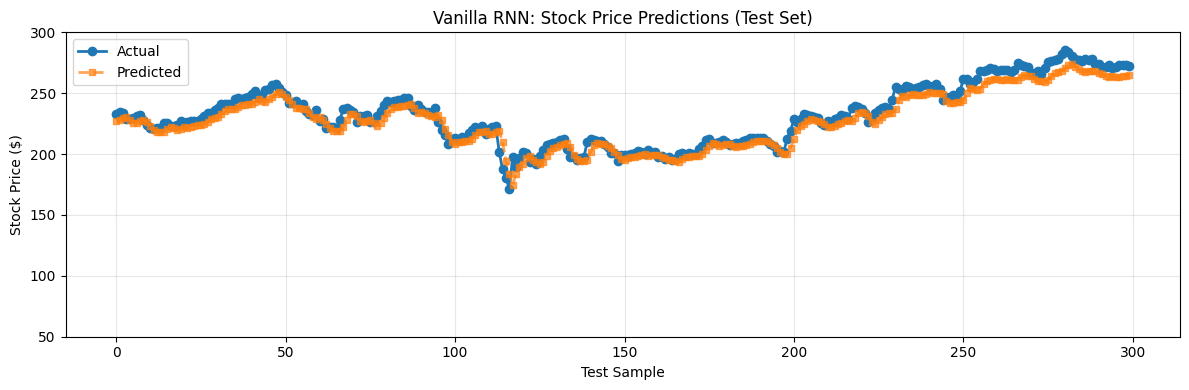

In [ ]:
test_vanilla_rnn(vanilla_rnn, X_train_stock, y_train_stock, X_test_stock, y_test_stock)

**Task 1 - Question 4:** What can you say about the performance of this model? Explain.

**Answer:**

When training the network we can see from the results that the model is learning as the training loss decreases from epochs 1 to epochs 50. At epoch 1 the train loss is 0.041063, falling to 0.014591 by epoch 13, to 0.004520 by epoch 21 and ending at 0.000290 by epoch 50. This decreasing trend it is an example of the learning process, where the forward propagation computes the total loss and the backward propagation calculates the gradients of the loss each time step and sets the weight (Lecture 6, RNN Forward/Backward propagation).

This exercise is facing a regression problems, which is when the output is numerical. Therefore the loss function used for regression is MSE/MAE, in this case MSE is the performance metric being used for the train/test and training curve. Lecture 3 states that overfitting is when there’s good performance on the training data and poor generalisation on other data, however that is not the case here as the model generalises well. The final test MSE is 0.000862 where as the final train MSE is slightly lowers, both values are small (both on the normalised scale 0-1).

The Vanilla RNN performance well here and is suitable in this exercise as it can use hidden state memory to predict stock prices more accuratley. This is because the model uses sequential data and according to week 6 it depends strictly on what came before them. Overall, the model learns and performs well, the train and test MSE are quite low, the model does not show signs of overfitting and memory is used to make a more accurate prediction.

**Task 1 - Question 5:** Try training and testing a vanilla RNN which has a hidden_size of 64. Keep the input size, number of layers and output size the same as before. How does this impact performance?

**Answer:**

In this exercise I have kept the input size, number of layers and output size the same however the hidden size has increased from 8 to 64. This decision has negatively impacted the performance of the model as the model despite having more hidden to hidden weights it became more complex however the test error because greater than the previous model. The results show that train loss was fairly similar in both models with 0.000236 in the first and 0.000234 in the second. However the test MSE in the first was 0000862 and higher in the second model with 0.001021. Lecture 3 states that a sign of overfitting is when the model generalises poorly on data other than the training data, which is evident in the larger model. Also the graph shows that the predicted and actual stock prices are very similar, however we can see that the the model with the hidden size does not fit as well as the previous model. Overall, we can see that the small model was fitting the data and generalised where as when the hidden size increased the model became complex, which did not improve performance and instead risked overfitting.


Epoch 1/50 - Train Loss: 0.129100
Epoch 2/50 - Train Loss: 0.131853
Epoch 3/50 - Train Loss: 0.028388
Epoch 4/50 - Train Loss: 0.044638
Epoch 5/50 - Train Loss: 0.042018
Epoch 6/50 - Train Loss: 0.029756
Epoch 7/50 - Train Loss: 0.021942
Epoch 8/50 - Train Loss: 0.027570
Epoch 9/50 - Train Loss: 0.025308
Epoch 10/50 - Train Loss: 0.018909
Epoch 11/50 - Train Loss: 0.025780
Epoch 12/50 - Train Loss: 0.023345
Epoch 13/50 - Train Loss: 0.021178
Epoch 14/50 - Train Loss: 0.014518
Epoch 15/50 - Train Loss: 0.015027
Epoch 16/50 - Train Loss: 0.013944
Epoch 17/50 - Train Loss: 0.011279
Epoch 18/50 - Train Loss: 0.011084
Epoch 19/50 - Train Loss: 0.011002
Epoch 20/50 - Train Loss: 0.007911
Epoch 21/50 - Train Loss: 0.005954
Epoch 22/50 - Train Loss: 0.005635
Epoch 23/50 - Train Loss: 0.002232
Epoch 24/50 - Train Loss: 0.002222
Epoch 25/50 - Train Loss: 0.001129
Epoch 26/50 - Train Loss: 0.004923
Epoch 27/50 - Train Loss: 0.002285
Epoch 28/50 - Train Loss: 0.003531
Epoch 29/50 - Train Loss: 0.0

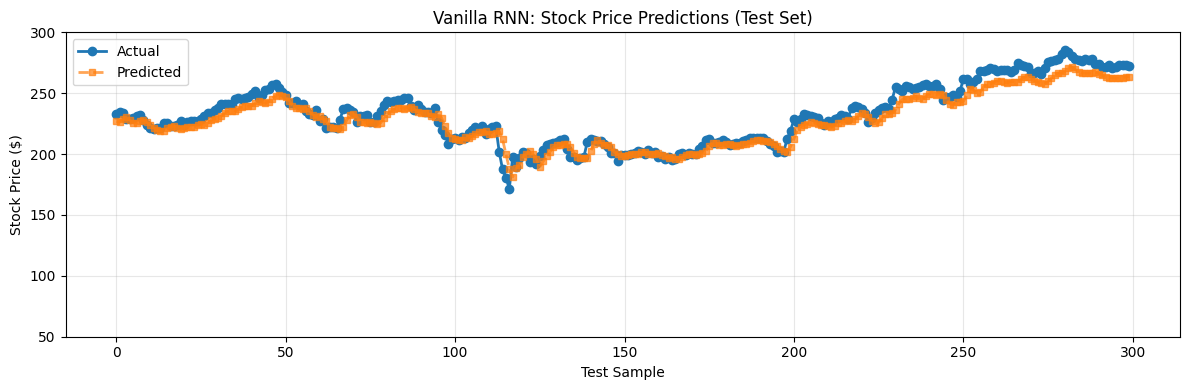

In [ ]:
#TODO Write code here to train and test the Vanilla RNN model on the stock data. Use the provided functions and classes defined above to complete the task.

vanilla_rnn_64 = VanillaRNN(input_size=1, hidden_size=64, num_layers=1, output_size=1)

vanilla_losses_train_64, vanilla_losses_test_64 = train_vanilla_rnn(
    vanilla_rnn_64, X_train_stock, y_train_stock, X_test_stock, y_test_stock, epochs=50
)

test_vanilla_rnn(vanilla_rnn_64, X_train_stock, y_train_stock, X_test_stock, y_test_stock)

**Task 1 - Question 6:** Now, instead of changing the hidden size, set the number of RNN layers to 3 while keeping a small hidden size (8). How does this affect performance?

**Answer:**

In this exercise, I kept the original hidden size of 8 however I set the number of RNN layers to 3 rather than 1. The results show that the deeper RNN performed worse than the models with a hidden size of 64 and 8. The final train MSE for hidden size 8 was 0.000236 and 0.000243 for hidden size 64, where as the 3 layer model has a train loss of 0.023344. Similarly the 3 layer model’s performance failed in the test MSE with a value of 0.135464, where as the other models got 0.000862 (for hidden size 8) and 0.001021. In question 5 we can see that the model failed to improve however showed good performance on training data, the 3 layer model has shown that it doesn’t not learn the task at all. This is evident during the training of the network where epoch 1 is 0.237292, increases to 0.47226 then decreases to 0.024162 by epoch 50.

Other than the train and test loss, the graph is a key indication that the model is not performing well as we can see a straight horizontal line at stock price 150 and the model completely ignores the upwards trend of the actual price, where as in hidden size 8 and 64 the predicted price used the temporal to learn the patterns of the actual price.

According to lecture 6, backward propagation through time (BPTT), a very long sequence and doing many backward calculations can be computationally expensive and can lead to an exploding gradient. This is common in deep RNN’s such as the 3 layer model in this exercise. This is reiterated in week 6 lecture 6 (key takeaways slide), a disadvantage of the basic design of a RNN is back propagation, which can lead to forgetting the pattern over long sequences.

Epoch 1/50 - Train Loss: 0.237292
Epoch 2/50 - Train Loss: 0.128646
Epoch 3/50 - Train Loss: 0.065783
Epoch 4/50 - Train Loss: 0.034732
Epoch 5/50 - Train Loss: 0.027520
Epoch 6/50 - Train Loss: 0.034996
Epoch 7/50 - Train Loss: 0.044981
Epoch 8/50 - Train Loss: 0.049383
Epoch 9/50 - Train Loss: 0.047226
Epoch 10/50 - Train Loss: 0.041001
Epoch 11/50 - Train Loss: 0.033951
Epoch 12/50 - Train Loss: 0.028819
Epoch 13/50 - Train Loss: 0.027149
Epoch 14/50 - Train Loss: 0.028831
Epoch 15/50 - Train Loss: 0.032172
Epoch 16/50 - Train Loss: 0.034904
Epoch 17/50 - Train Loss: 0.035593
Epoch 18/50 - Train Loss: 0.034202
Epoch 19/50 - Train Loss: 0.031659
Epoch 20/50 - Train Loss: 0.029147
Epoch 21/50 - Train Loss: 0.027552
Epoch 22/50 - Train Loss: 0.027205
Epoch 23/50 - Train Loss: 0.027882
Epoch 24/50 - Train Loss: 0.029011
Epoch 25/50 - Train Loss: 0.029970
Epoch 26/50 - Train Loss: 0.030337
Epoch 27/50 - Train Loss: 0.030012
Epoch 28/50 - Train Loss: 0.029186
Epoch 29/50 - Train Loss: 0.0

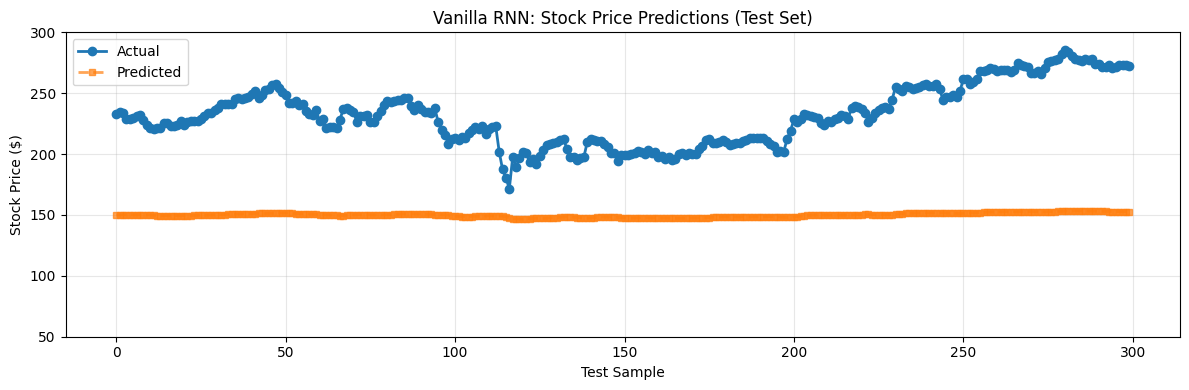

In [ ]:
#TODO Write code here to train and test the Vanilla RNN model on the stock data. Use the provided functions and classes above to complete the task.

vanilla_rnn_3layers = VanillaRNN(input_size=1, hidden_size=8, num_layers=3, output_size=1)

vanilla_losses_train_3, vanilla_losses_test_3 = train_vanilla_rnn(
    vanilla_rnn_3layers, X_train_stock, y_train_stock, X_test_stock, y_test_stock, epochs=50
)

test_vanilla_rnn(vanilla_rnn_3layers, X_train_stock, y_train_stock, X_test_stock, y_test_stock)

**Task 1 - Question 7:** Of the three vanilla RNN models above, which one would you prefer? Why?

**Answer:**

I would prefer the first model with a hidden size of 8 and a single layer vanilla RNN. The results show a final train MSE (0.000236) and a final test MSE (0.000862), which is the cheapest and lowest of the three models. Lecture 3 (Model Evaluation) states that the testing set provides an unbiased evaluation and the MSE is among the metrics used to assess how well a model performs on unseen data. Out of the three models the results shows model with the lowest test error (0.000862). Although model 2 uses the same number of layers, increasing the hidden size to 64 did not improve the model as we can see from the train MSE (0.000243) and test MSE (0.001021). This model has a higher test error than model 1, also during week 3 lecture it is stated that model with a high variance leads to an overly complex model and overfitting. Over model 1 performs better than models 2 and 3, which is also evident in the graph.

## Task 2: LSTM for Sentiment Analysis
In this task, we will use RNNs for sentiment classification tasks.

For this task, we will use the IMDB movie reviews dataset. A description of this dataset is available at: https://huggingface.co/datasets/stanfordnlp/imdb.  

Let's first load our dataset.

In [ ]:
imdb_dataset = load_dataset("stanfordnlp/imdb")

X_train_text = imdb_dataset["train"]["text"]
y_train_imdb = np.array(imdb_dataset["train"]["label"])
X_test_text = imdb_dataset["test"]["text"]
y_test_imdb = np.array(imdb_dataset["test"]["label"])

print(f"Loaded {len(X_train_text)} training and {len(X_test_text)} test IMDB reviews.")
print(f"Training set shape: {len(X_train_text)} reviews")
print(f"Test set shape: {len(X_test_text)} reviews")
print(f"Label distribution - Train: {np.sum(y_train_imdb)} positive, {len(y_train_imdb)-np.sum(y_train_imdb)} negative")
print(f"Label distribution - Test: {np.sum(y_test_imdb)} positive, {len(y_test_imdb)-np.sum(y_test_imdb)} negative")

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Loaded 25000 training and 25000 test IMDB reviews.
Training set shape: 25000 reviews
Test set shape: 25000 reviews
Label distribution - Train: 12500 positive, 12500 negative
Label distribution - Test: 12500 positive, 12500 negative


Next, we will preprocess the data so it can be used by an RNN. First, we build a vocabulary from the 500 most common words in the training set. This vocabulary will be helpful later on to associate words to numbers, and then use these numbers for training our models.

In [ ]:
max_words = 500
all_train_tokens = [word for text in X_train_text for word in text.lower().split()] # Get all unique words from the training text
word_counts = Counter(all_train_tokens) # Count occurrences of each word
most_common = [word for word, _ in word_counts.most_common(max_words - 2)] # Get the most common words, leaving space for <PAD> and <UNK>
word_index = {word: idx + 2 for idx, word in enumerate(most_common)} # Map words to indices
word_index["<PAD>"] = 0 #use 0 for padding when sentences are not the same size
word_index["<UNK>"] = 1 #use 1 for unknown words not in the vocabulary

print(f"Built vocabulary with {len(word_index)} words.")

Built vocabulary with 500 words.


We will now convert the reviews into token sequences using the vocabulary defined above, with a maximum length of 100 words. If a review has more than 100 words, we truncate it. If it has fewer, we pad it using "\<PAD\>" (index 0). Words that are not in the vocabulary are mapped to "\<UNK\>" (index 1). Note that we are simply doing a pre-processing step that encodes words as integers, since neural networks only accept numbers as inputs.

In [ ]:
def texts_to_sequences(texts, word_index, max_len):
    sequences = []
    for text in texts:
        tokens = [word_index.get(word, 1) for word in text.lower().split()][:max_len] #Get encoding of words to integer numbers from the word_index, use 1 for unknown words, and limit to max_len
        if len(tokens) < max_len:
            tokens += [0] * (max_len - len(tokens)) #Pad the sequence with 0s to make it of length max_len
        sequences.append(tokens)
    return np.array(sequences)

max_length = 100
X_train_imdb = texts_to_sequences(X_train_text, word_index, max_length)
X_test_imdb = texts_to_sequences(X_test_text, word_index, max_length)

print(f"Training sequences shape: {X_train_imdb.shape}")
print(f"Test sequences shape: {X_test_imdb.shape}")

X_train_imdb[0], y_train_imdb[0]  # Display the first training sequence and its label

Training sequences shape: (25000, 100)
Test sequences shape: (25000, 100)


(array([  9,   1,   9, 226,   1,  34,  57, 433,   1,  77,   5,  35,   2,
          1,  11,   1,  12,  50,  12,  14,  82,   1,   8,   1,   9,  81,
          1,  11,  29,  82,  12,  14,   1,  31,   1,   1,  46,  12, 125,
          1,   6,   1,  10,   1,   1,  99,   3, 376,   5, 129,   1,   1,
          9,  61,  62,   6,  67,  10,  16,   1,  13,  93, 131,   7,   1,
        197,   3, 185,   1,   1,   1,   1,   1,  36, 438,   6,   1, 292,
         53,  64,  43,   1,   8,   1,  53, 438,   6,   1,  42,   1,   6,
        242,  45, 391,   5,   1,  19,  48,   2,   1]),
 np.int64(0))

Now, we will convert our sequence data to tensors, and verify shapes.

In [ ]:
X_train_lstm = torch.LongTensor(X_train_imdb)
y_train_lstm = torch.FloatTensor(y_train_imdb)
X_test_lstm = torch.LongTensor(X_test_imdb)
y_test_lstm = torch.FloatTensor(y_test_imdb)

print(f"Tensor shapes - Train: {X_train_lstm.shape}, Test: {X_test_lstm.shape}")
print(f"Labels - Train: {y_train_lstm.shape}, Test: {y_test_lstm.shape}")

Tensor shapes - Train: torch.Size([25000, 100]), Test: torch.Size([25000, 100])
Labels - Train: torch.Size([25000]), Test: torch.Size([25000])


Next, we will define a vanilla sentiment RNN, similar to the one used in Task 1. Note that the model uses `nn.Embedding` to map token IDs (our integer numbers associated to words previously) to dense vectors (actual representations that can be "trained"). We will study embeddings in more detail next week when we cover Transformers. For now, you can check the documentation here: https://docs.pytorch.org/docs/2.12/generated/torch.nn.Embedding.html.

In [ ]:
class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, output_size=1):
        super(SentimentRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim) #To create an embedding layer that maps each word index to a dense vector representation of the specified embedding dimension
        self.rnn = nn.RNN(embedding_dim, hidden_size, num_layers, batch_first=True, nonlinearity="tanh") #To create an RNN layer that processes the embedded sequences with the specified hidden size, number of layers, and nonlinearity
        self.fc = nn.Linear(hidden_size, output_size) #To create a fully connected layer that maps the hidden state to the output size
        self.sigmoid = nn.Sigmoid() #To create a sigmoid activation function to squash the output to a range between 0 and 1 for binary classification

    def forward(self, x):
        embedded = self.embedding(x) #Pass the input through the embedding layer to get dense vector representations of the words
        out, _ = self.rnn(embedded) #Pass the embedded sequences through the RNN layer
        out = out[:, -1, :] #Take the last time step's output
        out = self.fc(out) #Pass the output through the fully connected layer
        out = self.sigmoid(out) #Apply the sigmoid activation function
        return out

**Task 2 - Question 1:** Why do we have self.sigmoid = nn.Sigmoid() as the final component of our SentimentRNN network?

**Answer:**

self.sigmoid = nn.Sigmoid() is the final component of our network as this task uses sentiment classification, which is a binary classification problem, and as stated in lecture 2 (comparing activation functions) sigmoid is the activiation function used in binary classification. Furthermore sigmoid maps any real value input to a value in 0 or 1, as stated in the lecture “produces a soft decision instead of a hard 0/1”. This is important as self.fc produces a real number and sigmoid gives us a probability between 0 to 1, which is what we need.   

Next, we will define a function for training our SentimentRNN. We will use binary cross-entropy as the loss, and Adam as the optimiser.

In [ ]:
def train_rnn(model, X_train, y_train, epochs=5, batch_size=32, lr=0.001):
    criterion = nn.BCELoss() #To define the loss function as Binary Cross Entropy (BCE) for binary classification tasks
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) #To define the optimizer as Adam with the specified learning rate

    train_losses = []
    dataset = TensorDataset(X_train, y_train) #Create a dataset from the training data and labels
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True) #Create a DataLoader to iterate through the dataset in batches, shuffling the data for each epoch

    for epoch in range(epochs):
        model.train() #Set the model to training mode to apply the updates appropriately during training
        epoch_loss = 0

        for X_batch, y_batch in loader:
            outputs = model(X_batch).squeeze() #Pass the batch of input sequences through the model to get predictions and remove any extra dimensions
            loss = criterion(outputs, y_batch) #compute the loss between the model's predictions and the true labels

            optimizer.zero_grad() #To clear the gradients of all optimized tensors before the backward pass
            loss.backward() #To compute the gradient of the loss with respect to the model parameters
            optimizer.step() #update the model parameters based on the computed gradients

            epoch_loss += loss.item()

        train_loss = epoch_loss / len(loader)
        train_losses.append(train_loss)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}")
    return train_losses



**Task 2 - Question 2:** We are using nn.BCELoss() as loss function in this task. What is the idea of this type of loss?

**Answer:**

Nn.BCELoss() is also known as Binary Cross-Entropy Loss. This is a Binary Classification Loss function, as stated in lecture 1 (Loss Function), binary classification predicts two classes (0 or 1) and the model outputs a probability of belonging to class 1. The formula given in the lecture for this loss function is: L =
-(1/n)Σ[yᵢlog(ŷᵢ) + (1-yᵢ)log(1-ŷᵢ)]. The idea of this loss function is to see how far the models predicted probability is from the true label. Week 1 lecture 2 states that a low loss means the model is performing well. This is evident in the binary classification example where the true label is 1 and the predicted is 0.9 (0.105 loss) and the mean Binary Cross-Entropy Loss is 0.612.

Now, we will train our SentimentRNN using the function we just defined. We use 32 hidden units and 1 layer. We also we an embedding dimension of 64 (again, the role of embeddings will become clear next week!). Please note that running this cell may take a few minutes.

Epoch 1/5 - Train Loss: 0.6957
Epoch 2/5 - Train Loss: 0.6907
Epoch 3/5 - Train Loss: 0.6847
Epoch 4/5 - Train Loss: 0.6752
Epoch 5/5 - Train Loss: 0.6724
Sentiment RNN trained.


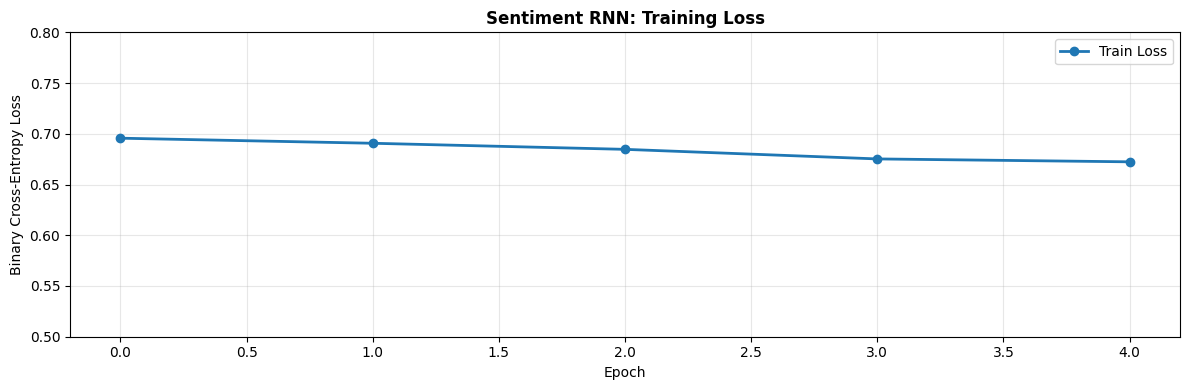

In [ ]:
sentiment_rnn = SentimentRNN(vocab_size=max_words, embedding_dim=64, hidden_size=32, num_layers=1)
rnn_losses = train_rnn(sentiment_rnn, X_train_lstm, y_train_lstm, epochs=5, batch_size=32)
print("Sentiment RNN trained.")

plt.figure(figsize=(12, 4))

plt.plot(rnn_losses, label='Train Loss', linewidth=2, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.ylim(0.5, 0.8)
plt.title('Sentiment RNN: Training Loss', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Let's define a function to test our SentimentRNN, and then evaluate on our test set.

In [ ]:
def test_rnn(model, X_test, y_test):
    model.eval() #Set the model to evaluation mode to disable update of weights and other training-specific behaviors
    with torch.no_grad():
        test_pred_rnn = (model(X_test).squeeze() > 0.5).float().numpy() #Classify an example as positive if the sigmoid score is > 0.5
    baseline_test_acc = (test_pred_rnn == y_test.numpy()).mean()
    return baseline_test_acc

In [ ]:
test_sentiment_rnn = test_rnn(sentiment_rnn, X_test_lstm, y_test_lstm)
print(f"Vanilla Sentiment RNN Test Accuracy: {test_sentiment_rnn:.4f}")

Vanilla Sentiment RNN Test Accuracy: 0.5678


As expected from the training loss above, the test accuracy is quite poor; the model predicts sentiment correctly only about half of the time. We could tune vanilla RNN hyperparameters, for example by adding more layers, but first let's see whether we can do better at the same depth using an LSTM.

Let's first define our SentimentLSTM model.

In [ ]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, output_size=1):
        super(SentimentLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim) #To create an embedding layer that maps each word index to a dense vector representation of the specified embedding dimension
        self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers, batch_first=True) #To create an LSTM layer that processes the embedded sequences with the specified hidden size and number of layers
        self.fc = nn.Linear(hidden_size, output_size) #To create a fully connected layer that maps the hidden state to the output size
        self.sigmoid = nn.Sigmoid() #To create a sigmoid activation function to squash the output to a range between 0 and 1 for binary classification

    def forward(self, x):
        embedded = self.embedding(x) #Pass the input through the embedding layer to get dense vector representations of the words
        out, _ = self.lstm(embedded) #Pass the embedded sequences through the LSTM layer
        out = out[:, -1, :] #Take the last time step's output
        out = self.fc(out) #Pass the output through the fully connected layer
        out = self.sigmoid(out) #Apply the sigmoid activation function
        return out

**Task 2 - Question 3:** What changed in this definition compared to our previous Sentiment RNN?

**Answer:**

In this task we are discussing the Long Short Term Memory (LSTM). Lecture 6, states that LSTM uses both long term and short term memories of the past. Also it introduces a concept of “Gates”, a cell in LSTM which uses three of these gates (input gate, hidden state output gate, forget gate). The previous sentiment RNN passes a single hidden state, whereas LSTM maintains two memories one being the short term memory hidden state (ht) and long term memory (ct), (Lecture 6, week 2). Furthermore, another change is that during the recurrent layer the vanillaRNN uses self.rnn=nn.RNN, where as LSTM layer is self.lstm=nn.lstm. Finally, as stated in the lecture 6 key takeaways LSTM is good for maintaining long range dependencies and is computationally cheaper than vanilla RNN.

Now, let's define the training function for the SentimentLSTM model.

In [ ]:
def train_lstm(model, X_train, y_train, epochs=10, batch_size=32, lr=0.001):
    criterion = nn.BCELoss() #To define the loss function as Binary Cross Entropy (BCE) for binary classification tasks
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) #To define the optimizer as Adam with the specified learning rate

    train_losses = []

    dataset = TensorDataset(X_train, y_train) #Create a dataset from the training data and labels
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True) #Create a DataLoader to iterate through the dataset in batches, shuffling the data for each epoch

    for epoch in range(epochs):
        model.train() #Set the model to training mode to apply the updates appropriately during training
        epoch_loss = 0

        for X_batch, y_batch in loader:
            outputs = model(X_batch).squeeze() #Pass the batch of input sequences through the model to get predictions and remove any extra dimensions
            loss = criterion(outputs, y_batch) #compute the loss between the model's predictions and the true labels

            optimizer.zero_grad() #clear the gradients of all optimized tensors before the backward pass
            loss.backward() #compute the gradient of the loss with respect to the model parameters
            optimizer.step() #update the model parameters based on the computed gradients

            epoch_loss += loss.item()

        train_loss = epoch_loss / len(loader)
        train_losses.append(train_loss)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}")

    return train_losses

Now let's train that network, using our vocabulary size, an embedding dimension of 64, a hidden size of 32 and 1 hidden layer.

Epoch 1/5 - Train Loss: 0.6886
Epoch 2/5 - Train Loss: 0.6277
Epoch 3/5 - Train Loss: 0.5531
Epoch 4/5 - Train Loss: 0.5072
Epoch 5/5 - Train Loss: 0.4817
Sentiment LSTM trained.


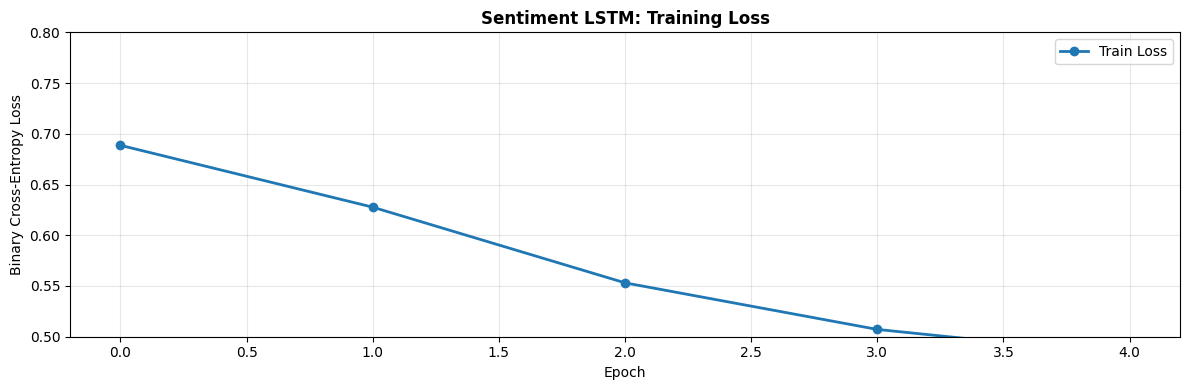

In [ ]:
sentiment_lstm = SentimentLSTM(vocab_size=max_words, embedding_dim=64, hidden_size=32, num_layers=1)
lstm_losses = train_lstm(sentiment_lstm, X_train_lstm, y_train_lstm, epochs=5, batch_size=32)
print("Sentiment LSTM trained.")

plt.figure(figsize=(12, 4))

plt.plot(lstm_losses, label='Train Loss', linewidth=2, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Sentiment LSTM: Training Loss', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.ylim(0.5, 0.8)
plt.legend()

plt.tight_layout()
plt.show()

Let's define a test function.

In [ ]:
def test_lstm(model, X_test, y_test):
    model.eval() #Set the model to evaluation mode to disable update of weights and other training-specific behaviors
    with torch.no_grad(): #Disable gradient computation for evaluation
        test_pred_lstm = (model(X_test).squeeze() > 0.5).float().numpy() #Classify an example as positive if the sigmod score is > 0.5
    lstm_test_acc = (test_pred_lstm == y_test.numpy()).mean()
    return lstm_test_acc

Now use that function to compute LSTM accuracy on the test set.

In [ ]:
test_sentiment_lstm = test_lstm(sentiment_lstm, X_test_lstm, y_test_lstm)
print(f"Sentiment LSTM Test Accuracy: {test_sentiment_lstm:.4f}")

Sentiment LSTM Test Accuracy: 0.7482


In [ ]:
print("To summarise...")
print(f"Vanilla RNN test accuracy: {test_sentiment_rnn:.4f}")
print(f"LSTM final test accuracy:   {test_sentiment_lstm:.4f}")
print(f"Performance improvement:    {(test_sentiment_lstm - test_sentiment_rnn):.4f}")

To summarise...
Vanilla RNN test accuracy: 0.5678
LSTM final test accuracy:   0.7482
Performance improvement:    0.1803


**Task 2 - Question 4:** Why do you think implementing LSTM cells outperforms vanilla RNN in this sentiment classification task?

**Answer:**

Sentiment relies on context across the sequence and in week 6 we learnt that sequential data depends strictly on what came before (memory of the past). A limitation of vanilla RNNs is that back propagation through time is computationally expensive and long range dependencies may be lost. This is one of the main reasons why implementing LSTM outperforms the vanilla RNN, LSTM excels in maintaining data over a long duration where are the vanilla RNN forgets it. The vanilla RNN performs poorly as tasks pass through a single hidden state where as the LSTM uses short term and long term memories of the past. During week 6 key takeaways it is stated that LSTM is useful for maintaining long range dependencies and computationally cheaper than vanilla RNN. This is evident in the results of the task above where the vanilla RNN test accuracy is 0.5678 and increases to 0.7482 for LSTM final test accuracy, with a performance improvement of 0.1803.

**Task 2 - Question 5:** Experiment with a Sentiment LSTM using different hyperparameters (for example, increase the hidden size to 64 or add more layers). Be careful not to make your model too big, otherwise it may take a long time to train and test. You can simply use the train and test functions defined above, with different hyperparameter values. Explain: what changes do you observe? what can you conclude from these differences?

**Answer:**

In this task I experimented with a sentiment LSTM using a similar approach to task 1. In the first experiment I selected a hidden size of 64 and a num layer of 1. The results show epoch 1 at 0.6880 and a decrease to 0.4677 at epoch 5. The test accuracy is 0.7540 which is a slight increase from the previous baseline LSTM (0.7482). In the second experiment I selected a hidden size of 32 and num layer of 2. The results show epoch 1 at 0.6822 then a slight decrease to 0.5221 at epoch 5. What I observed was during the wider parameter (hidden size 64) the training data set fit well with training loss of 0.4677, where as the baseline model had a final loss of 0.4817 at epoch 5. Secondly, during the deeper parameter (num layers 2) although the training loss decreased the value was higher at epoch 5. Overall all three models performed relatively similar. Overall conclusion shows that the models performance improved more when the architecture was changed from vanillaRNN to LSTM rather than changing the LSTM hyper parameters. In lecture 6 it states that a larger hidden size provides more memory of the past and a larger depth provides more representation, however both hyper parameters increase computation.


In [ ]:
#TODO - Write the code you need here

# Experiment 1: hidden size = 32 and num_layers = 1
sentiment_lstm_h64 = SentimentLSTM(vocab_size=max_words, embedding_dim=64, hidden_size=64, num_layers=1)
lstm_losses_h64 = train_lstm(sentiment_lstm_h64, X_train_lstm, y_train_lstm, epochs=5, batch_size=32)
test_acc_h64 = test_lstm(sentiment_lstm_h64, X_test_lstm, y_test_lstm)
print(f"LSTM (hidden_size=64, num_layers=1) Test Accuracy: {test_acc_h64:.4f}")

# Experiment 2: hidden size = 32 and num_layers = 2
sentiment_lstm_l2 = SentimentLSTM(vocab_size=max_words, embedding_dim=64, hidden_size=32, num_layers=2)
lstm_losses_l2 = train_lstm(sentiment_lstm_l2, X_train_lstm, y_train_lstm, epochs=5, batch_size=32)
test_acc_l2 = test_lstm(sentiment_lstm_l2, X_test_lstm, y_test_lstm)
print(f"LSTM (hidden_size=32, num_layers=2) Test Accuracy: {test_acc_l2:.4f}")

# Baseline for comparison (from earlier in the lab): hidden_size=32, num_layers=1
print(f"\nBaseline LSTM (hidden_size=32, num_layers=1) Test Accuracy: {test_sentiment_lstm:.4f}")

Epoch 1/5 - Train Loss: 0.6880
Epoch 2/5 - Train Loss: 0.6705
Epoch 3/5 - Train Loss: 0.5442
Epoch 4/5 - Train Loss: 0.4943
Epoch 5/5 - Train Loss: 0.4677
LSTM (hidden_size=64, num_layers=1) Test Accuracy: 0.7540
Epoch 1/5 - Train Loss: 0.6822
Epoch 2/5 - Train Loss: 0.6739
Epoch 3/5 - Train Loss: 0.6217
Epoch 4/5 - Train Loss: 0.5650
Epoch 5/5 - Train Loss: 0.5221
LSTM (hidden_size=32, num_layers=2) Test Accuracy: 0.7433

Baseline LSTM (hidden_size=32, num_layers=1) Test Accuracy: 0.7482


## Task 3: Encoder-Decoder LSTM on a Synthetic Task
In our lecture, we explored encoder-decoder RNNs for tasks such as translation between languages. We described the two big parts of the encoder-decoder RNN: 1) an encoder and 2) a decoder. It turns out that we can use an LSTM implementation as the encoder and/or decoder.

In this task, we will implement an encoder-decoder LSTM on a synthetic sequence-to-sequence problem.

We will create a synthetic dataset with controlled difficulty so we can experiment with an encoder-decoder architecture. We will generate synthetic source and target sequences. The target will be the reversed source sequence.  

In [ ]:
src_sentences = []
tgt_sentences = []

rng = np.random.default_rng(42) #Random number generator for reproducibility
token_pool = [f'tok{i}' for i in range(1, 41)]
num_samples = 10000

for _ in range(num_samples):
    seq_len = int(rng.integers(3, 7)) #create sequences of length between 3 and 6 (3 to 6 tokens)
    words = rng.choice(token_pool, size=seq_len, replace=True).tolist() #Select tokens randomly from the pool
    source = ' '.join(words) #Create the source sentence by joining the selected tokens with spaces
    target = ' '.join(reversed(words)) #Create the target sentence by reversing the order of the tokens in the source sentence
    src_sentences.append(source) #Add the source sentence to the list of source sentences
    tgt_sentences.append(target) #Add the target sentence to the list of target sentences

print(f'Created {len(src_sentences)} synthetic pairs (reverse-sequence task).')

Created 10000 synthetic pairs (reverse-sequence task).


Let's explore some example synthetic pairs.

In [ ]:
print(f"\nExample pairs:")
for i in range(5):
    print(f"  Source: {src_sentences[i]}")
    print(f"  Target: {tgt_sentences[i]}\n")

src_lengths = [len(s.split()) for s in src_sentences]
tgt_lengths = [len(s.split()) for s in tgt_sentences]


Example pairs:
  Source: tok31 tok27 tok18
  Target: tok18 tok27 tok31

  Source: tok35 tok4 tok28 tok9
  Target: tok9 tok28 tok4 tok35

  Source: tok22 tok40 tok30
  Target: tok30 tok40 tok22

  Source: tok29 tok32 tok21 tok6 tok34 tok19
  Target: tok19 tok34 tok6 tok21 tok32 tok29

  Source: tok15 tok8 tok38 tok32 tok26
  Target: tok26 tok32 tok38 tok8 tok15



Next, we build a shared vocabulary for the synthetic tokens and include special tokens for padding, start of sequence and end of sequence.

In [ ]:
def build_vocab(sentences, max_vocab=1000):
    # Build a frequency-based vocabulary so common words are retained.
    counts = Counter(word for sent in sentences for word in sent.split())
    vocab = {'<PAD>': 0, '<START>': 1, '<END>': 2, '<UNK>': 3} #Initialize the vocabulary with special tokens for padding, start, end, and unknown words
    for word, _ in counts.most_common(max_vocab - len(vocab)):
        vocab[word] = len(vocab)
    return vocab

src_vocab = build_vocab(src_sentences)
tgt_vocab = build_vocab(tgt_sentences)

print(f"Source vocabulary size: {len(src_vocab)}")
print(f"Target vocabulary size: {len(tgt_vocab)}")


Source vocabulary size: 44
Target vocabulary size: 44


**Task 3 - Question 1:** Why do we need to use a vocabulary in this task?

**Answer:**

In this task the data used is text tokens (synthetic tokens) and neural networks requires numbers to function. This is evident in week 6 lecture (Additional Example) which states xt and yt are actually words and not numbers. Also the lecture key takeaways states that RNNs may require some additional data pre-processing spending on the task and an example task was encoding words into numeric vectors. We use vocabulary as it gives us a numeric mapping. In lecture 6 (Additional Example) the first step is is construct a vocabulary of unique characters, which in this task is done using build_vocab where each token is assigned an integer index.

We then use these vocabularies to encode the sentence pairs.

In [ ]:
def encode_sentence(sent, vocab, max_len=20):
    indices = [vocab['<START>']] #Start with the <START> token
    unk_idx = vocab.get('<UNK>', vocab['<PAD>']) #Get the index for unknown words, defaulting to the padding index if <UNK> is not in the vocabulary
    for word in sent.split()[:max_len-2]: #Reserve space for <START> and <END>
        indices.append(vocab.get(word, unk_idx)) #Get the index of the word from the vocabulary, or use the unknown index if the word is not found
    indices.append(vocab['<END>']) #Add the <END> token to the end of the sequence
    while len(indices) < max_len: #Pad the sequence with <PAD> tokens until it reaches the maximum length
        indices.append(vocab['<PAD>']) #Add the <PAD> token to the end of the sequence until it reaches the maximum length
    return indices[:max_len] #Return the encoded sequence, ensuring it does not exceed the maximum length

src_encoded = [encode_sentence(s, src_vocab) for s in src_sentences] #Encode each source sentence into a sequence of indices based on the source vocabulary
tgt_encoded = [encode_sentence(s, tgt_vocab) for s in tgt_sentences] #Encode each target sentence into a sequence of indices based on the target vocabulary

print(f"Encoded {len(src_encoded)} source sequences")
print(f"Encoded {len(tgt_encoded)} target sequences")

Encoded 10000 source sequences
Encoded 10000 target sequences


Next, we split our synthetic dataset into training (80%) and test (20%).

In [ ]:
split_idx = int(len(src_encoded) * 0.8)
X_train_enc = torch.LongTensor(src_encoded[:split_idx])
y_train_enc = torch.LongTensor(tgt_encoded[:split_idx])
X_test_enc = torch.LongTensor(src_encoded[split_idx:])
y_test_enc = torch.LongTensor(tgt_encoded[split_idx:])

print(f"Training pairs: {X_train_enc.shape[0]}")
print(f"Test pairs: {X_test_enc.shape[0]}")

Training pairs: 8000
Test pairs: 2000


Now we define our encoder-decoder LSTM.
Note how the encoder and decoder are defined as separate modules:
the encoder reads the input sequence and returns a hidden state,
while the decoder uses that state to produce the output sequence one token at a time.

In [ ]:
class EncoderLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers):
        super(EncoderLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0) #To create an embedding layer that maps each word index to a dense vector representation of the specified embedding dimension, with padding index set to 0
        self.rnn = nn.LSTM(embedding_dim, hidden_size, num_layers, batch_first=True) #To create an LSTM layer that processes the embedded sequences with the specified hidden size and number of layers, with batch_first=True to indicate that the input tensor has the batch size as the first dimension

    def forward(self, x):
        embedded = self.embedding(x)
        _, hidden = self.rnn(embedded)
        return hidden

class DecoderLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers):
        super(DecoderLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0) #To create an embedding layer that maps each word index to a dense vector representation of the specified embedding dimension, with padding index set to 0
        self.rnn = nn.LSTM(embedding_dim, hidden_size, num_layers, batch_first=True) #To create an LSTM layer that processes the embedded sequences with the specified hidden size and number of layers, with batch_first=True to indicate that the input tensor has the batch size as the first dimension
        self.fc = nn.Linear(hidden_size, vocab_size) #To create a fully connected layer that maps the hidden state to the vocabulary size, allowing the model to predict the next word in the sequence

    def forward(self, x, hidden):
        embedded = self.embedding(x) #Pass the input through the embedding layer to get dense vector representations of the words
        out, hidden = self.rnn(embedded, hidden) #Pass the embedded sequences through the LSTM layer, using the provided hidden state from the encoder
        out = self.fc(out) #Pass the output of the LSTM layer through the fully connected layer to get the predicted word scores for each time step
        return out, hidden

**Task 3 - Question 2:** What difference can you see in the architecture of the encoder compared to the decoder? Why do you think is the reason for this difference?

**Answer:**

The architecture difference is that the decoder has an extra fully connect layer (self.fc=nn.Linear). As seen in the task this layer maps the hidden state to the vocabulary size, which allows the model to predict the future words in the sequence. However the encoder and the decoder share the LSTM backbone and the embedding. The reason for this difference is because they hold different roles. The decoder creates output tokens using the linear layer (nn.Linear) to generate vocabulary scores, where as the encoder’s role is to summaries and read, which is why it does not require a linear layer.


Next, we instantiate the encoder and decoder with an embedding dimension of 64, a hidden size of 128 and one hidden layer.

In [ ]:
lstm_encoder = EncoderLSTM(vocab_size=len(src_vocab), embedding_dim=64, hidden_size=128, num_layers=1)
lstm_decoder = DecoderLSTM(vocab_size=len(tgt_vocab), embedding_dim=64, hidden_size=128, num_layers=1)

print(f"Encoder LSTM instantiated with {len(src_vocab)} input vocab size")
print(f"Decoder LSTM instantiated with {len(tgt_vocab)} output vocab size")

Encoder LSTM instantiated with 44 input vocab size
Decoder LSTM instantiated with 44 output vocab size


Now we define a training function that uses cross-entropy loss and the Adam optimiser.

In [ ]:
def train_seq2seq_rnn(encoder, decoder, X_train, y_train, epochs=20, lr=0.001, batch_size=64):
    enc_optimizer = torch.optim.Adam(encoder.parameters(), lr=lr) #To define the optimizer for the encoder as Adam with the specified learning rate
    dec_optimizer = torch.optim.Adam(decoder.parameters(), lr=lr) #To define the optimizer for the decoder as Adam with the specified learning rate

    criterion = nn.CrossEntropyLoss(ignore_index=0) #define the loss function as Cross Entropy Loss, ignoring the padding index (0) during loss computation
    train_losses = []

    dataset = TensorDataset(X_train, y_train)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True) #Load the training data in batches for efficiency

    for epoch in range(epochs):
        encoder.train() #Set the encoder to training mode to apply the updates appropriately during training
        decoder.train() #Set the decoder to training mode to apply the updates appropriately during training

        total_loss = 0.0

        for x_batch, y_batch in loader:
            hidden = encoder(x_batch) #Pass the input batch through the encoder to get the hidden state
            dec_input = y_batch[:, :-1] #Get the input for the decoder (excluding the last token)
            dec_target = y_batch[:, 1:] #Get the target for the decoder (excluding the first token)

            dec_output, _ = decoder(dec_input, hidden) #Pass the decoder input and hidden state through the decoder
            loss = criterion(dec_output.reshape(-1, dec_output.size(-1)), dec_target.reshape(-1)) #Compute the loss between the predicted and actual outputs
            enc_optimizer.zero_grad()
            dec_optimizer.zero_grad()
            loss.backward()

            # Clip gradients to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0) #Clip the gradients of the encoder parameters to a maximum norm of 1.0 to prevent exploding gradients during training
            torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1.0)

            enc_optimizer.step() #Update the encoder parameters based on the computed gradients
            dec_optimizer.step() #Update the decoder parameters based on the computed gradients
            total_loss += loss.item()

        epoch_loss = total_loss / max(1, len(loader))
        train_losses.append(epoch_loss)

        print(f"Epoch {epoch+1}/{epochs} - Encoder-decoder train loss: {epoch_loss:.4f}")

    return train_losses

Let's use the training function defined above to train our encoder-decoder LSTM on the synthetic sequence task. This may take a few minutes.

Epoch 1/20 - Encoder-decoder train loss: 3.3388
Epoch 2/20 - Encoder-decoder train loss: 3.0380
Epoch 3/20 - Encoder-decoder train loss: 2.9964
Epoch 4/20 - Encoder-decoder train loss: 2.8708
Epoch 5/20 - Encoder-decoder train loss: 2.5539
Epoch 6/20 - Encoder-decoder train loss: 2.0899
Epoch 7/20 - Encoder-decoder train loss: 1.6647
Epoch 8/20 - Encoder-decoder train loss: 1.3252
Epoch 9/20 - Encoder-decoder train loss: 1.0876
Epoch 10/20 - Encoder-decoder train loss: 0.8926
Epoch 11/20 - Encoder-decoder train loss: 0.7416
Epoch 12/20 - Encoder-decoder train loss: 0.6347
Epoch 13/20 - Encoder-decoder train loss: 0.5514
Epoch 14/20 - Encoder-decoder train loss: 0.4709
Epoch 15/20 - Encoder-decoder train loss: 0.4071
Epoch 16/20 - Encoder-decoder train loss: 0.3541
Epoch 17/20 - Encoder-decoder train loss: 0.3164
Epoch 18/20 - Encoder-decoder train loss: 0.2824
Epoch 19/20 - Encoder-decoder train loss: 0.2533
Epoch 20/20 - Encoder-decoder train loss: 0.2238
Final training loss: 0.2238


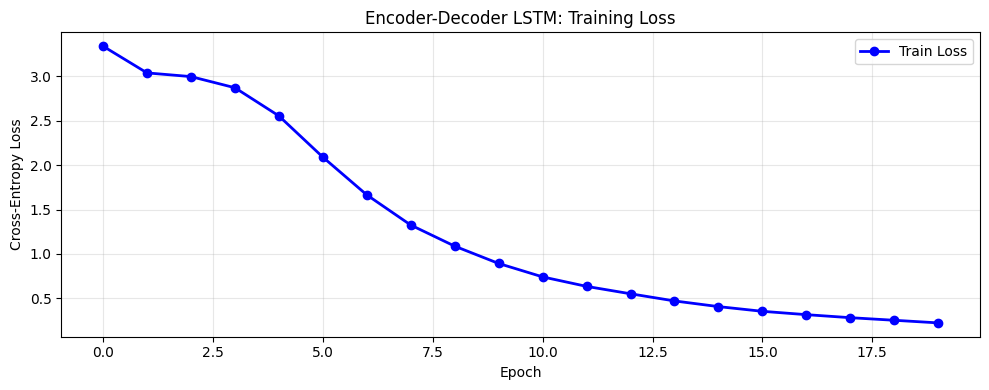

In [ ]:
train_loss = train_seq2seq_rnn(lstm_encoder, lstm_decoder, X_train_enc, y_train_enc, epochs=20, lr=0.001)
print(f"Final training loss: {train_loss[-1]:.4f}")

# Plot Vanilla RNN baseline training and evaluation metrics
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_loss, label='Train Loss', linewidth=2, marker='o', color='blue')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Encoder-Decoder LSTM: Training Loss')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

Let's define a function to evaluate our model.

In [ ]:
def evaluate_seq2seq_metrics(encoder, decoder, X_data, y_data, batch_size=64):
    encoder.eval() #Set the encoder to evaluation mode to disable update of weights and other training-specific behaviors
    decoder.eval() #Set the decoder to evaluation mode to disable update of weights and other training-specific behaviors

    total_tokens = 0
    correct_tokens = 0

    dataset = TensorDataset(X_data, y_data)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False) #Load the evaluation data in batches for efficiency

    with torch.no_grad():
        for x_batch, y_batch in loader:
            hidden = encoder(x_batch) #Pass the input batch through the encoder to get the hidden state

            dec_input = y_batch[:, :-1] #Get the input for the decoder (excluding the last token)
            dec_target = y_batch[:, 1:] #Get the target for the decoder (excluding the first token)
            dec_output, _ = decoder(dec_input, hidden) #Evaluate the decoder with the input and hidden state

            pred_tokens = torch.argmax(dec_output, dim=2) #Get the predicted tokens
            mask = (dec_target != 0) & (dec_target != 2) # Ignore padding and the forced <END> token so the metric reflects the copied word itself.
            correct_tokens += ((pred_tokens == dec_target) & mask).sum().item() #count the number of correct predictions for the masked tokens
            total_tokens += mask.sum().item()

    accuracy = correct_tokens / total_tokens if total_tokens > 0 else 0.0
    return accuracy

And let's also define some helper functions to print a few predicted target sequences from our encoder-decoder LSTM to manually check.

In [ ]:
def decode_sentence(indices, vocab):
    reverse_vocab = {v: k for k, v in vocab.items()} #Create a reverse mapping from indices to words for decoding the predicted sequence back into a human-readable format
    tokens = []
    for idx in indices:
        token = reverse_vocab.get(int(idx), '<UNK>') #Get the corresponding token for the index, defaulting to '<UNK>' if the index is not found in the reverse vocabulary
        if token in ('<PAD>', '<START>'): #Ignore padding and start tokens in the decoded output
            continue
        if token == '<END>': #Stop decoding when the end token is reached, as it indicates the end of the sequence
            break
        tokens.append(token) #Add the decoded token to the list of tokens to be returned
    return ' '.join(tokens).strip() or '[EMPTY]' #Return the decoded sentence as a string, joining the tokens with spaces and stripping any leading/trailing whitespace. If no tokens were decoded (e.g., if the sequence was empty), return '[EMPTY]' to indicate that the output is empty.

def decode_model_output(encoder, decoder, x_batch, y_batch, vocab):
    hidden = encoder(x_batch) #Pass the input batch through the encoder to get the hidden state for the decoder
    dec_input = y_batch[:, :-1] #Get the input for the decoder (excluding the last token) to feed into the decoder for generating predictions
    dec_output, _ = decoder(dec_input, hidden) #Get the decoder output for the input batch and hidden state
    pred_tokens = torch.argmax(dec_output, dim=2) #Get the predicted tokens from the decoder output
    return decode_sentence(pred_tokens[0].tolist(), vocab)

def print_example_predictions(encoder, decoder, X_test_enc, y_test_enc, split_idx, tgt_vocab, num_examples=5):
    print("\n--- EXAMPLE PREDICTIONS ---")

    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        for i in range(num_examples):
            x_batch = X_test_enc[i:i+1]
            y_batch = y_test_enc[i:i+1]

            source_sent = src_sentences[split_idx + i]
            target_sent = tgt_sentences[split_idx + i]

            pred_sent = decode_model_output(encoder, decoder, x_batch, y_batch, tgt_vocab)

            print(f"Source: {source_sent}")
            print(f"Predicted target: {pred_sent}")
            print(f"Target sequence: {target_sent}\n")

Now let's evaluate our encoder-decoder LSTM model, and print some example predictions.

In [ ]:
lstm_test_acc = evaluate_seq2seq_metrics(lstm_encoder, lstm_decoder, X_test_enc, y_test_enc)
print(f"Encoder-Decoder LSTM test token accuracy: {lstm_test_acc:.4f}")

print_example_predictions(lstm_encoder, lstm_decoder, X_test_enc, y_test_enc, split_idx, tgt_vocab, num_examples=5)

Encoder-Decoder LSTM test token accuracy: 0.9244

--- EXAMPLE PREDICTIONS ---
Source: tok31 tok16 tok21 tok39
Predicted target: tok39 tok21 tok16 tok31
Target sequence: tok39 tok21 tok16 tok31

Source: tok32 tok16 tok4 tok11
Predicted target: tok11 tok4 tok16 tok32
Target sequence: tok11 tok4 tok16 tok32

Source: tok37 tok2 tok33
Predicted target: tok33 tok2 tok37
Target sequence: tok33 tok2 tok37

Source: tok7 tok22 tok4
Predicted target: tok4 tok22 tok7
Target sequence: tok4 tok22 tok7

Source: tok32 tok3 tok24
Predicted target: tok24 tok3 tok32
Target sequence: tok24 tok3 tok32



**Task 3 - Question 3:** An encoder-decoder LSTM architecture as the one defined above worked quite well for this task. Why do you think that is the case? What do you think would have happened if we used a vanilla RNN inside the encoder/decoder?

**Answer:**

The reason the encoder-decoder LSTM architecture works well or better than the vanilla RNN would have is because this is a sequence to sequence task, which is what the encoder-decoder is created for. As stated in week 6 (week 2), in a sequence to sequence model the encoder-decoder separates the reading of the input sequence from the writing of the output sequence. This is crucial as the first word of the output can not be generated until we have read the whole input sentence. The encoder summaries the input into the context vector c whilst the decoder creates the reversed sequence to match the context vector. The LSTM architecture is suitable in this task as it preserves patterns in the sequence. LSTM uses both long term memories and short term memories of the past whilst protecting the gradient. If the vanilla RNN was used inside the encoder-decoder it would not perform well as it uses a single hidden state forward and doesn’t have long term memory, therefore forgetting some of the prior input tokens. Lecture 6 states that vanilla RNN is computationally more expensive than a LSTM architecture and leads to forgetting over long sequences.


**Some final optional tasks (not graded):**
1. Experiment with encoder-decoder LSTM hyperparameters. Look for meaningful differences and explain why they might occur. Avoid making the network too large, or training may take a long time.
2. Create a second synthetic task (for example, copy task, sorted tokens, or cyclic shift) and compare learning behaviour.
